In [89]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split


df = pd.read_csv('enhanced_student_habits_performance_dataset.csv')
df.head()

,student_id,age,gender,major,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,...,screen_time,study_environment,access_to_tutoring,family_income_range,parental_support_level,motivation_level,exam_anxiety_score,learning_style,time_management_score,exam_score
0,100000,26,Male,Computer Science,7.645367,3.0,0.1,Yes,70.3,6.2,...,10.9,Co-Learning Group,Yes,High,9,7,8,Reading,3.0,100
1,100001,28,Male,Arts,5.700000,0.5,0.4,No,88.4,7.2,...,8.3,Co-Learning Group,Yes,Low,7,2,10,Reading,6.0,99
2,100002,17,Male,Arts,2.400000,4.2,0.7,No,82.1,9.2,...,8.0,Library,Yes,High,3,9,6,Kinesthetic,7.6,98
3,100003,27,Other,Psychology,3.400000,4.6,2.3,Yes,79.3,4.2,...,11.7,Co-Learning Group,Yes,Low,5,3,10,Reading,3.2,100
4,100004,25,Female,Business,4.700000,0.8,2.7,Yes,62.9,6.5,...,9.4,Quiet Room,Yes,Medium,9,1,10,Reading,7.1,98


In [90]:
df.shape

(80000, 31)

In [91]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [92]:
df.info()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     80000 non-null  int64  
 1   age                            80000 non-null  int64  
 2   gender                         80000 non-null  object 
 3   major                          80000 non-null  object 
 4   study_hours_per_day            80000 non-null  float64
 5   social_media_hours             80000 non-null  float64
 6   netflix_hours                  80000 non-null  float64
 7   part_time_job                  80000 non-null  object 
 8   attendance_percentage          80000 non-null  float64
 9   sleep_hours                    80000 non-null  float64
 10  diet_quality                   80000 non-null  object 
 11  exercise_frequency             80000 non-null  int64  
 12  parental_education_level       80000 non-null 

,0
student_id,0
age,0
gender,0
major,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0


In [93]:
# Remove unnecessary columns
df = df.drop(columns=['student_id','index', 'attendance_percentage','exercise_frequency','diet_quality','parental_education_level','internet_quality','mental_health_rating','extracurricular_participation','exam_score'], errors='ignore')
df.head()

,age,gender,major,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,sleep_hours,previous_gpa,semester,...,social_activity,screen_time,study_environment,access_to_tutoring,family_income_range,parental_support_level,motivation_level,exam_anxiety_score,learning_style,time_management_score
0,26,Male,Computer Science,7.645367,3.0,0.1,Yes,6.2,4.00,5,...,0,10.9,Co-Learning Group,Yes,High,9,7,8,Reading,3.0
1,28,Male,Arts,5.700000,0.5,0.4,No,7.2,4.00,7,...,5,8.3,Co-Learning Group,Yes,Low,7,2,10,Reading,6.0
2,17,Male,Arts,2.400000,4.2,0.7,No,9.2,3.79,4,...,5,8.0,Library,Yes,High,3,9,6,Kinesthetic,7.6
3,27,Other,Psychology,3.400000,4.6,2.3,Yes,4.2,4.00,6,...,3,11.7,Co-Learning Group,Yes,Low,5,3,10,Reading,3.2
4,25,Female,Business,4.700000,0.8,2.7,Yes,6.5,4.00,4,...,2,9.4,Quiet Room,Yes,Medium,9,1,10,Reading,7.1


In [94]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,sleep_hours,previous_gpa,semester,stress_level,social_activity,screen_time,parental_support_level,motivation_level,exam_anxiety_score,time_management_score
count,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000
mean,22.004288,4.174388,2.501366,1.997754,7.017417,3.602448,4.497338,5.012478,2.500225,9.673029,5.479438,5.488525,8.508475,5.499132
std,3.745570,2.004135,1.445441,1.155992,1.467377,0.462876,2.295312,1.953174,1.704292,2.780869,2.873327,2.867782,1.796411,2.603534
min,16.000000,0.000000,0.000000,0.000000,4.000000,1.640000,1.000000,1.000000,0.000000,0.300000,1.000000,1.000000,5.000000,1.000000
25%,19.000000,2.800000,1.200000,1.000000,6.000000,3.270000,2.000000,3.600000,1.000000,7.800000,3.000000,3.000000,7.000000,3.200000
50%,22.000000,4.125624,2.500000,2.000000,7.000000,3.790000,5.000000,5.000000,2.000000,9.700000,5.000000,5.000000,10.000000,5.500000
75%,25.000000,5.500000,3.800000,3.000000,8.000000,4.000000,7.000000,6.400000,4.000000,11.600000,8.000000,8.000000,10.000000,7.800000
max,28.000000,12.000000,5.000000,4.000000,12.000000,4.000000,8.000000,10.000000,5.000000,21.000000,10.000000,10.000000,10.000000,10.000000


In [95]:
#removing duplicates
df = df.drop_duplicates()


In [96]:
#remove rows where sleep_hours is too high or too low
Q1 = df['sleep_hours'].quantile(0.25)
Q3 = df['sleep_hours'].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df['sleep_hours'] < (Q1 - 1.5 * IQR)) | (df['sleep_hours'] > (Q3 + 1.5 * IQR)))]


In [97]:
# Remove rows where study_hours_per_day is too high or too low
Q1 = df['study_hours_per_day'].quantile(0.25)
Q3 = df['study_hours_per_day'].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df['study_hours_per_day'] < (Q1 - 1.5 * IQR)) |
          (df['study_hours_per_day'] > (Q3 + 1.5 * IQR)))]

In [98]:
df.shape

(79370, 22)

In [99]:
#define total social hours per day
df['total_social_hours'] = df['netflix_hours'] + df['social_media_hours']

In [100]:
#define focus ratio
df['focus_ratio'] = df['study_hours_per_day'] / (
    df['study_hours_per_day'] + df['total_social_hours'] + 1
)

In [101]:
#define task completed
threshold = 0.5

df['task_completed'] = (
    df['focus_ratio'] +
    np.random.normal(0, 0.1, len(df))  #noise
    > threshold
).astype(int)

In [102]:
df['task_completed'].value_counts()


,count
task_completed,
0,52056
1,27314


In [103]:
features = [
    'age',
    'gender',
    'part_time_job',
    'study_hours_per_day',
    'sleep_hours',
    'total_social_hours'
]

X = df[features].copy()
y = df['task_completed'].copy()

In [104]:
#    - One-hot encode categorical columns
X = pd.get_dummies(X, columns=['gender', 'part_time_job'], drop_first=True)

In [105]:
#    - Scale numeric columns
num_cols = ['age', 'study_hours_per_day', 'sleep_hours', 'total_social_hours']
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])


In [106]:
#apply smote
smote = SMOTE(random_state=42)
X_bal, y_bal = smote.fit_resample(X, y)

In [107]:
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_bal, y_bal,
    test_size=0.2,
    random_state=42,
    stratify=y_bal
)

In [108]:
print("y (original):")
print(y.value_counts())

print("\ny_bal (after SMOTE on full dataset):")
print(y_bal.value_counts())

print("\ny_train_bal (after split):")
print(y_train_bal.value_counts())

print("\ny_test_bal (after split):")
print(y_test_bal.value_counts())

y (original):
task_completed
0    52056
1    27314
Name: count, dtype: int64

y_bal (after SMOTE on full dataset):
task_completed
1    52056
0    52056
Name: count, dtype: int64

y_train_bal (after split):
task_completed
1    41645
0    41644
Name: count, dtype: int64

y_test_bal (after split):
task_completed
0    10412
1    10411
Name: count, dtype: int64


In [109]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

model.fit(X_train_bal, y_train_bal)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, min_samples_split=20,
                       random_state=42)

In [110]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test_bal)

print("Accuracy:", round(accuracy_score(y_test_bal, y_pred), 3))
print("\nClassification Report:")
print(classification_report(y_test_bal, y_pred))


Accuracy: 0.808

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.77      0.80     10412
           1       0.79      0.85      0.82     10411

    accuracy                           0.81     20823
   macro avg       0.81      0.81      0.81     20823
weighted avg       0.81      0.81      0.81     20823



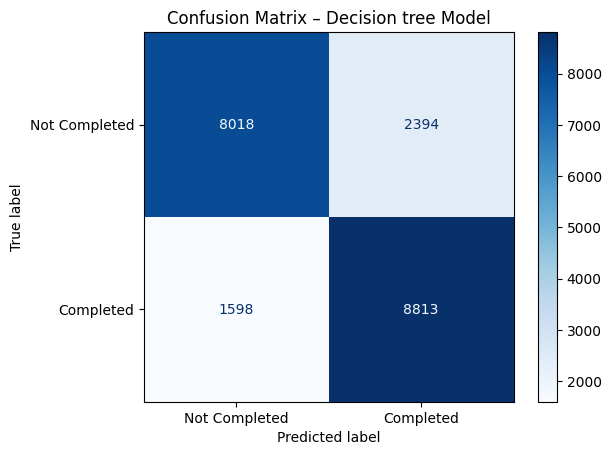

In [111]:
#evaluating the model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt



# Generate confusion matrix
cm = confusion_matrix(y_test_bal, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Not Completed', 'Completed'])

disp.plot(cmap='Blues')
plt.title("Confusion Matrix – Decision tree Model")
plt.show()

In [112]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

rf_model.fit(X_train_bal, y_train_bal)

RandomForestClassifier(max_depth=10, min_samples_leaf=5, min_samples_split=10,
                       n_estimators=200, random_state=42)

In [113]:
y_pred = rf_model.predict(X_test_bal)

In [114]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test_bal, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.79      0.82     10412
           1       0.81      0.85      0.83     10411

    accuracy                           0.82     20823
   macro avg       0.83      0.82      0.82     20823
weighted avg       0.83      0.82      0.82     20823



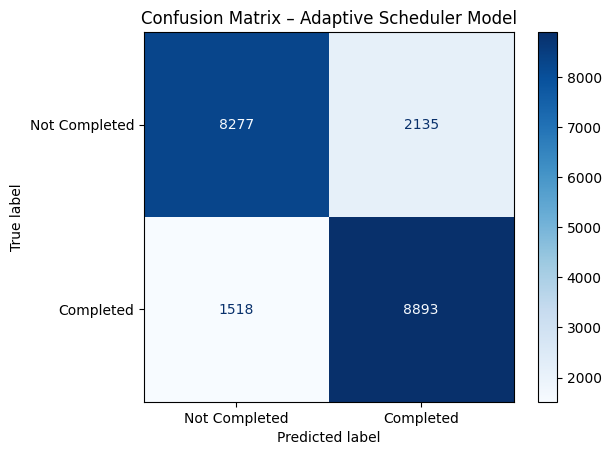

In [115]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test_bal, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Completed', 'Completed']
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix – Adaptive Scheduler Model")
plt.show()

In [116]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',  # helps with class imbalance
    random_state=42
)

log_model.fit(X_train_bal, y_train_bal)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [117]:
y_pred_lr = log_model.predict(X_test_bal)

In [118]:
from sklearn.metrics import classification_report

accuracy_lr = accuracy_score(y_test_bal, y_pred_lr)
print("Logistic Regression Accuracy:", accuracy_lr)

print("Classification Report (Logistic Regression):")
print(classification_report(y_test_bal, y_pred_lr))

Logistic Regression Accuracy: 0.8114104595879557
Classification Report (Logistic Regression):
              precision    recall  f1-score   support

           0       0.82      0.80      0.81     10412
           1       0.80      0.82      0.81     10411

    accuracy                           0.81     20823
   macro avg       0.81      0.81      0.81     20823
weighted avg       0.81      0.81      0.81     20823



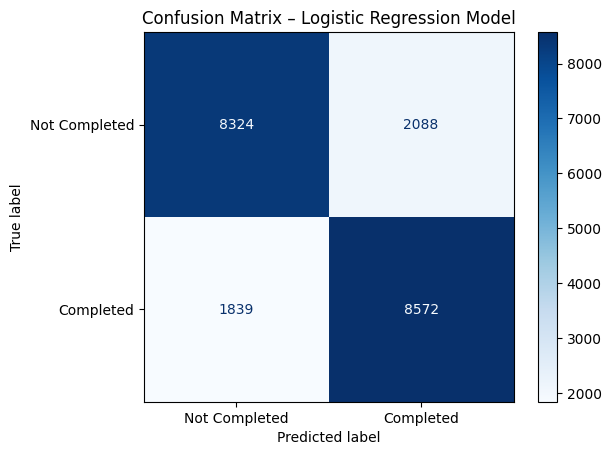

In [119]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_lr = confusion_matrix(y_test_bal, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=['Not Completed', 'Completed']
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix – Logistic Regression Model")
plt.show()